# Unsupervised analysis — SmartSeq

Goal: discover structure in the SmartSeq data **without** using the
Hypo/Norm labels, then compare what we found with the labels to decide
whether hypoxia is the dominant transcriptional axis.

Pipeline (one per cell line):

1. Wrap the expression matrix as a `scanpy.AnnData` object.
2. Scale → PCA → nearest-neighbour graph → UMAP.
3. **Leiden clustering** at several resolutions; pick the resolution that
   maximises the **silhouette score** in PCA space.
4. **KMeans** for `k = 2..6` as a sanity check; pick the `k` with the
   best silhouette.
5. Compare the best clustering against the ground-truth condition with
   Adjusted Rand Index (ARI) and Normalised Mutual Information (NMI).

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[1]))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(context="notebook", style="whitegrid")
RNG = 42

In [2]:
import scanpy as sc
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=80, facecolor="white")


def run_scanpy_pipeline(adata, n_pcs=30, n_neighbors=15, random_state=42):
    """Standard scanpy embedding pipeline.

    The teacher's data is already log-normalised on 3000 HVGs, so we skip
    `normalize_total` / `log1p` / `highly_variable_genes` and go straight to
    scaling + PCA.
    """
    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, n_comps=n_pcs, random_state=random_state)
    sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs, random_state=random_state)
    sc.tl.umap(adata, random_state=random_state)
    return adata


def silhouette_sweep_leiden(adata, resolutions, random_state=42):
    """Sweep Leiden resolution, scoring each clustering by silhouette in PCA space."""
    rows = []
    X_pca = adata.obsm["X_pca"]
    for res in resolutions:
        key = f"leiden_r{res:.2f}"
        sc.tl.leiden(
            adata,
            resolution=res,
            random_state=random_state,
            key_added=key,
            flavor="igraph",
            n_iterations=2,
            directed=False,
        )
        labels = adata.obs[key].astype(int).values
        n_clusters = len(np.unique(labels))
        sil = silhouette_score(X_pca, labels) if n_clusters > 1 else np.nan
        rows.append({"resolution": res, "n_clusters": n_clusters, "silhouette": sil, "key": key})
    return pd.DataFrame(rows)


def silhouette_sweep_kmeans(adata, ks, random_state=42):
    rows = []
    X_pca = adata.obsm["X_pca"]
    for k in ks:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10).fit(X_pca)
        sil = silhouette_score(X_pca, km.labels_)
        adata.obs[f"kmeans_k{k}"] = pd.Categorical(km.labels_.astype(str))
        rows.append({"k": k, "silhouette": sil})
    return pd.DataFrame(rows)


def label_agreement(adata, cluster_key):
    """Compare a clustering against the true condition labels."""
    truth = adata.obs["condition"].astype(str).values
    pred = adata.obs[cluster_key].astype(str).values
    ari = adjusted_rand_score(truth, pred)
    nmi = normalized_mutual_info_score(truth, pred)
    contingency = pd.crosstab(adata.obs["condition"], adata.obs[cluster_key])
    return ari, nmi, contingency

In [3]:
from src.utils import load_smartseq, to_anndata

CELL_LINES = ["MCF7", "HCC1806"]

## 1 — Build AnnData for both cell lines

In [4]:
adatas = {}
for cl in CELL_LINES:
    X, y = load_smartseq(cl, split="train")
    adatas[cl] = to_anndata(X, y, dataset=f"{cl}_SmartSeq")
    print(f"{cl}: {adatas[cl]}")

MCF7: AnnData object with n_obs × n_vars = 250 × 3000
    obs: 'condition'
    uns: 'dataset'
HCC1806: AnnData object with n_obs × n_vars = 182 × 3000
    obs: 'condition'
    uns: 'dataset'


## 2 — Run the scanpy pipeline (PCA, neighbours, UMAP)

In [5]:
for cl, a in adatas.items():
    run_scanpy_pipeline(a, n_pcs=30, n_neighbors=15)

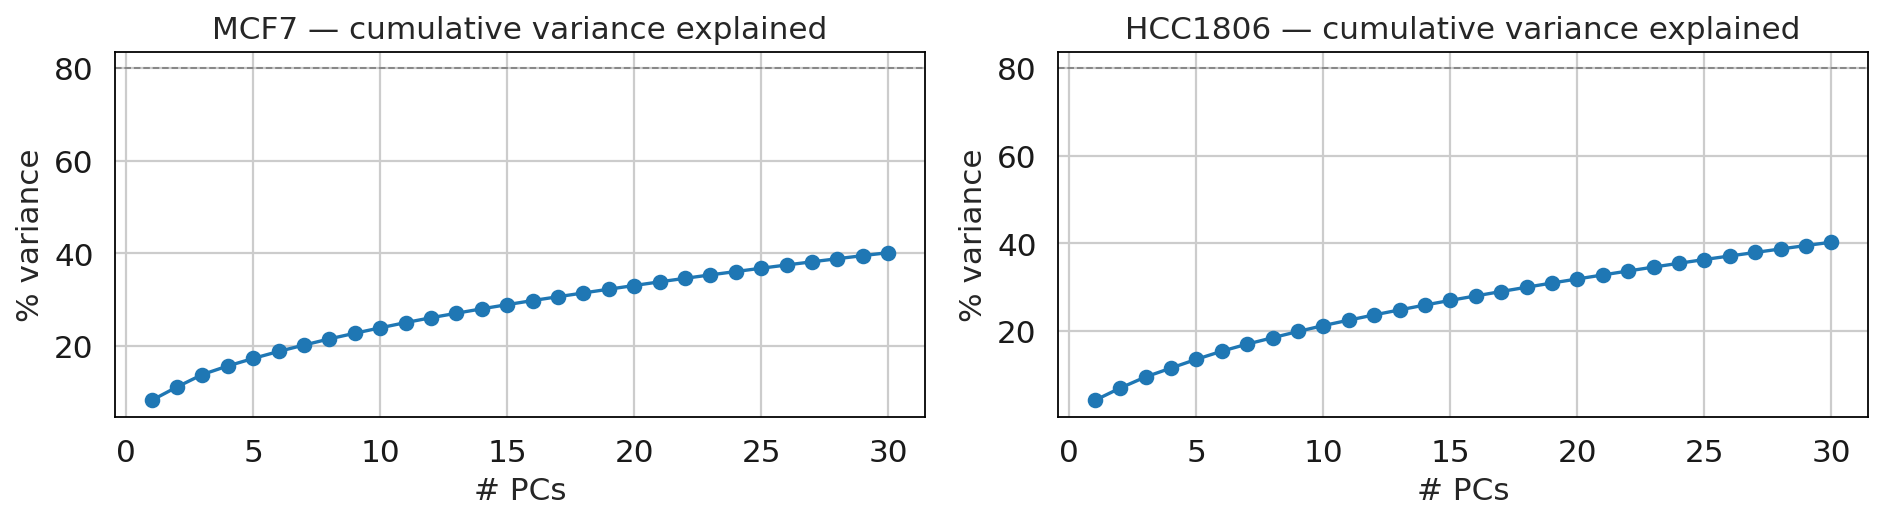

In [6]:
# Quick PCA elbow to justify the n_pcs choice.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, (cl, a) in zip(axes, adatas.items()):
    var = a.uns["pca"]["variance_ratio"]
    ax.plot(np.arange(1, len(var) + 1), np.cumsum(var) * 100, "o-")
    ax.axhline(80, ls="--", c="grey", lw=0.8)
    ax.set_title(f"{cl} — cumulative variance explained")
    ax.set_xlabel("# PCs")
    ax.set_ylabel("% variance")
plt.tight_layout()
plt.show()

**Reading this — choice for the next steps.** Neither cell line reaches the 80 % dashed line within 30 PCs: variance is spread thinly across many components (cumulative ≈ 40 % at PC30; PC1 alone is only ~8 % for MCF7 and ~4 % for HCC1806). That is normal for sparse scRNA-seq and means there is **no sharp elbow** to read off. We therefore keep the standard **30-PC** cut — enough to capture the leading biological structure while discarding the long noise tail — and use it for the neighbour graph and all silhouette scoring below. A much smaller cut (e.g. 5 PCs) would risk dropping the hypoxia axis, which for HCC1806 does not even sit on PC1 (see §8).

## 3 — UMAP coloured by the (held-out) condition

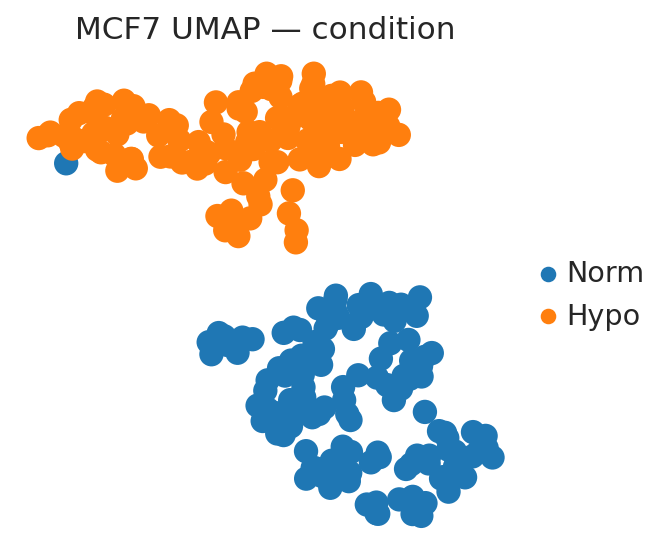

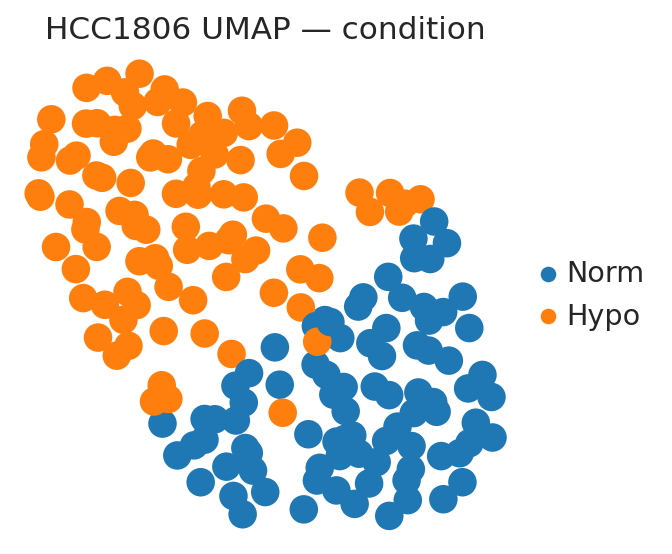

In [7]:
for cl, a in adatas.items():
    sc.pl.umap(a, color="condition", title=f"{cl} UMAP — condition", frameon=False, show=True)

**Reading this — choice for the next steps.** MCF7 shows two visually clean, well-separated Hypo/Norm islands: hypoxia looks like the dominant axis, so we expect clustering to recover it directly. HCC1806 cells are far more intermingled — gradients rather than discrete blobs — a warning that the largest source of variance here may *not* be hypoxia. This is why the next steps **do not assume 2 clusters**: we sweep Leiden resolution and KMeans `k`, score every partition, and then check agreement with the held-out labels (ARI/NMI).

If Hypo and Norm cells separate visually, the **dominant axis of variation in
the data is hypoxia** — encouraging for the supervised step. If they overlap
heavily, hypoxia may share its signal with other technical or biological
factors (cell cycle, batch, plate position for SmartSeq).

## 4 — Silhouette sweep: Leiden resolution

In [8]:
leiden_results = {}
for cl, a in adatas.items():
    df = silhouette_sweep_leiden(a, resolutions=[0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.5])
    leiden_results[cl] = df
    print(f"\n{cl} Leiden sweep:")
    print(df.to_string(index=False))


MCF7 Leiden sweep:
 resolution  n_clusters  silhouette          key
        0.1           2    0.227666 leiden_r0.10
        0.2           2    0.227666 leiden_r0.20
        0.3           3    0.128845 leiden_r0.30
        0.5           4    0.134452 leiden_r0.50
        0.8           6    0.114164 leiden_r0.80
        1.0           8    0.091968 leiden_r1.00
        1.5          11    0.061391 leiden_r1.50

HCC1806 Leiden sweep:
 resolution  n_clusters  silhouette          key
        0.1           1         NaN leiden_r0.10
        0.2           2    0.085041 leiden_r0.20
        0.3           2    0.085041 leiden_r0.30
        0.5           3    0.035954 leiden_r0.50
        0.8           5    0.056012 leiden_r0.80
        1.0           6    0.065664 leiden_r1.00
        1.5           9    0.016930 leiden_r1.50


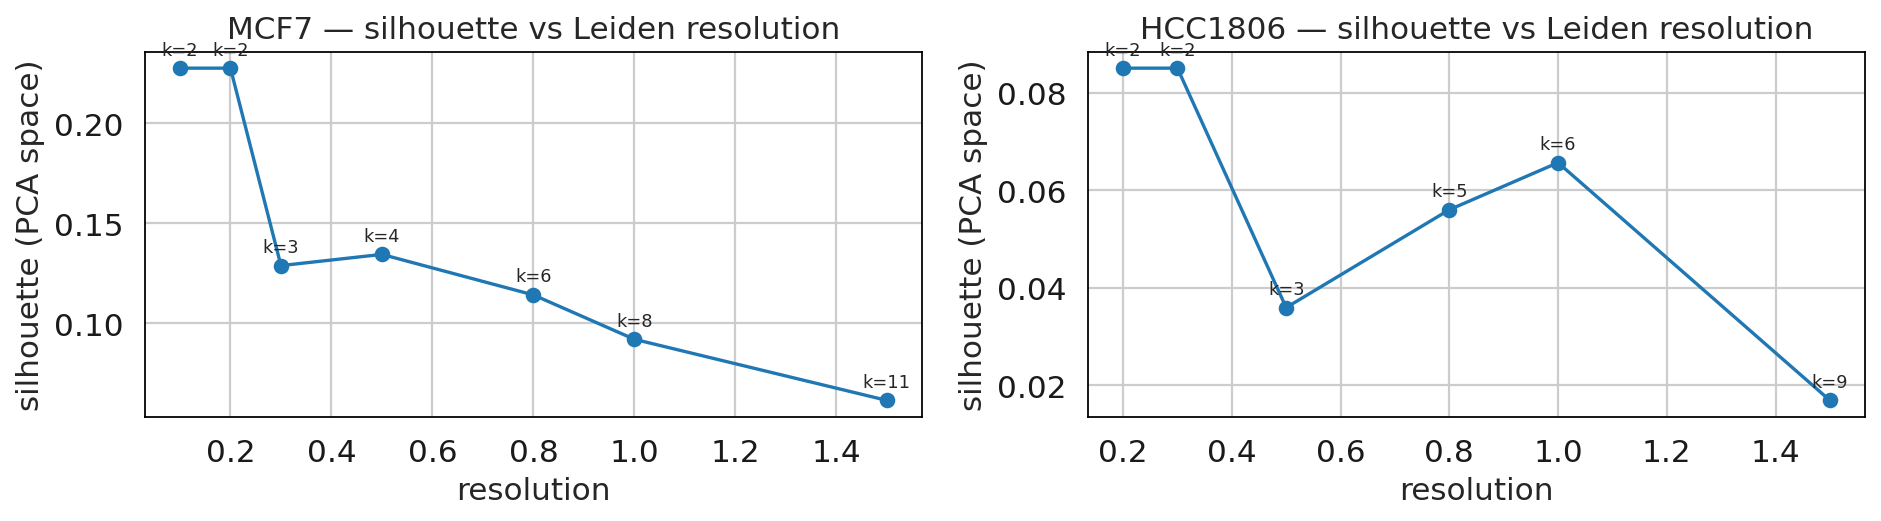

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, (cl, df) in zip(axes, leiden_results.items()):
    ax.plot(df["resolution"], df["silhouette"], "o-")
    for _, row in df.iterrows():
        ax.annotate(
            f"k={int(row['n_clusters'])}",
            (row["resolution"], row["silhouette"]),
            textcoords="offset points",
            xytext=(0, 6),
            fontsize=8,
            ha="center",
        )
    ax.set_title(f"{cl} — silhouette vs Leiden resolution")
    ax.set_xlabel("resolution")
    ax.set_ylabel("silhouette (PCA space)")
plt.tight_layout()
plt.show()

**Choice of resolution.** Silhouette falls monotonically with resolution for both lines as Leiden fragments the data into ever more clusters. The peak sits at the **lowest resolutions**: MCF7 res 0.10–0.20 → **2 clusters** (silhouette 0.23); HCC1806 res 0.20–0.30 → **2 clusters** (silhouette 0.09, with res 0.10 collapsing to a single cluster). We carry the **best-silhouette Leiden run** forward (§6). Encouragingly the silhouette-optimal partition is 2 clusters for both lines — matching the two known conditions — so the choice is not forced, it is what the geometry prefers.

## 5 — Silhouette sweep: KMeans `k`

In [10]:
kmeans_results = {}
for cl, a in adatas.items():
    df = silhouette_sweep_kmeans(a, ks=range(2, 7))
    kmeans_results[cl] = df
    print(f"\n{cl} KMeans sweep:")
    print(df.to_string(index=False))


MCF7 KMeans sweep:
 k  silhouette
 2    0.228208
 3    0.223044
 4    0.129669
 5    0.133433
 6    0.112334

HCC1806 KMeans sweep:
 k  silhouette
 2    0.459372
 3    0.084459
 4    0.092865
 5    0.101989
 6    0.100341


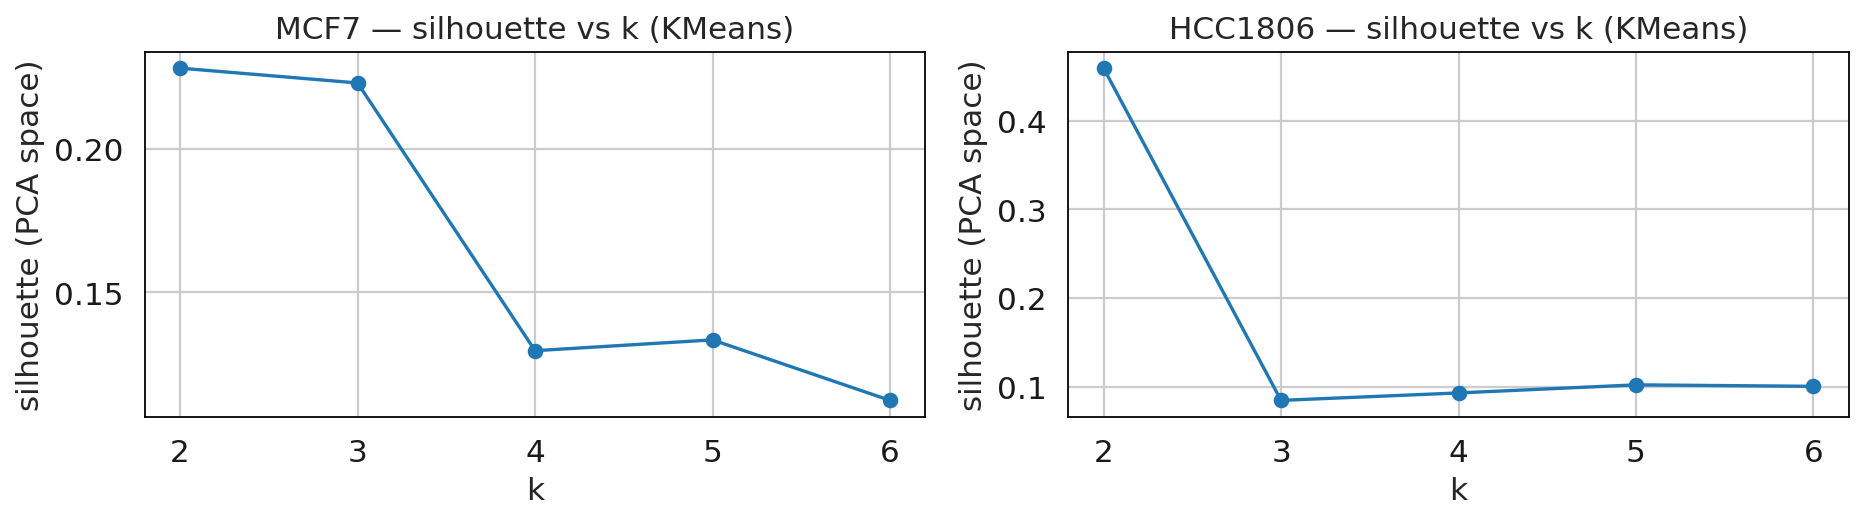

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, (cl, df) in zip(axes, kmeans_results.items()):
    ax.plot(df["k"], df["silhouette"], "o-")
    ax.set_title(f"{cl} — silhouette vs k (KMeans)")
    ax.set_xlabel("k")
    ax.set_ylabel("silhouette (PCA space)")
plt.tight_layout()
plt.show()

**Choice of `k`, and a caveat.** For MCF7, KMeans agrees with Leiden: `k=2` is optimal (silhouette 0.23), reinforcing the 2-group reading. For HCC1806 the picture is deceptive — **`k=2` wins the silhouette sweep decisively (0.46)**, far above any Leiden score, yet (§6) that partition has ARI ≈ 0. KMeans is latching onto a compact, high-variance split that is *not* hypoxia. We still carry the best-silhouette `k` forward, but this is exactly why we **never select a clustering on silhouette alone** — the next step validates against the ground-truth labels.

## 6 — Pick the best clustering and compare to ground truth

In [12]:
# Best Leiden by silhouette (per cell line).
results = []
for cl, a in adatas.items():
    best = leiden_results[cl].loc[leiden_results[cl]["silhouette"].idxmax()]
    best_kmeans = kmeans_results[cl].loc[kmeans_results[cl]["silhouette"].idxmax()]
    ari_l, nmi_l, cont_l = label_agreement(a, best["key"])
    ari_k, nmi_k, cont_k = label_agreement(a, f"kmeans_k{int(best_kmeans['k'])}")
    print(f"\n=== {cl} ===")
    print(
        f"Best Leiden: res={best['resolution']:.2f}  k={int(best['n_clusters'])}  "
        f"silhouette={best['silhouette']:.3f}  ARI={ari_l:.3f}  NMI={nmi_l:.3f}"
    )
    print(cont_l)
    print(
        f"\nBest KMeans: k={int(best_kmeans['k'])}  silhouette={best_kmeans['silhouette']:.3f}  "
        f"ARI={ari_k:.3f}  NMI={nmi_k:.3f}"
    )
    print(cont_k)
    results.append(
        {
            "cell_line": cl,
            "leiden_res": best["resolution"],
            "leiden_k": int(best["n_clusters"]),
            "leiden_silhouette": best["silhouette"],
            "leiden_ari": ari_l,
            "leiden_nmi": nmi_l,
            "kmeans_k": int(best_kmeans["k"]),
            "kmeans_silhouette": best_kmeans["silhouette"],
            "kmeans_ari": ari_k,
            "kmeans_nmi": nmi_k,
        }
    )
pd.DataFrame(results)


=== MCF7 ===
Best Leiden: res=0.10  k=2  silhouette=0.228  ARI=0.984  NMI=0.966
leiden_r0.10    0    1
condition             
Norm          125    1
Hypo            0  124

Best KMeans: k=2  silhouette=0.228  ARI=0.952  NMI=0.907
kmeans_k2    0    1
condition          
Norm         2  124
Hypo       123    1

=== HCC1806 ===
Best Leiden: res=0.20  k=2  silhouette=0.085  ARI=0.642  NMI=0.623
leiden_r0.20   0   1
condition           
Norm          85   0
Hypo          18  79

Best KMeans: k=2  silhouette=0.459  ARI=-0.003  NMI=0.028
kmeans_k2   0   1
condition        
Norm        4  81
Hypo       14  83


,cell_line,leiden_res,leiden_k,leiden_silhouette,leiden_ari,leiden_nmi,kmeans_k,kmeans_silhouette,kmeans_ari,kmeans_nmi
0,MCF7,0.1,2,0.227666,0.984000,0.966365,2,0.228208,0.952385,0.907189
1,HCC1806,0.2,2,0.085041,0.641557,0.623450,2,0.459372,-0.002840,0.027734


**Interpreting the table.** **MCF7:** Leiden res 0.10 gives near-perfect recovery (ARI 0.984, NMI 0.966; contingency ≈ diagonal), with KMeans `k=2` close behind (ARI 0.952) — a label-free pipeline essentially reconstructs the experiment. **HCC1806:** the two methods **diverge sharply** — Leiden recovers hypoxia reasonably (ARI 0.642) despite a tiny silhouette (0.085), while KMeans, despite the *highest* silhouette anywhere in this notebook (0.459), scores ARI ≈ 0 (strong geometry, wrong variable). Decision rule for the rest of the analysis: **trust ARI/NMI over silhouette, and trust graph-based Leiden over geometric KMeans** when the signal of interest is subtle. The low absolute silhouettes (0.08–0.23) are expected for sparse high-dimensional scRNA-seq.

## 7 — UMAP coloured by best clustering

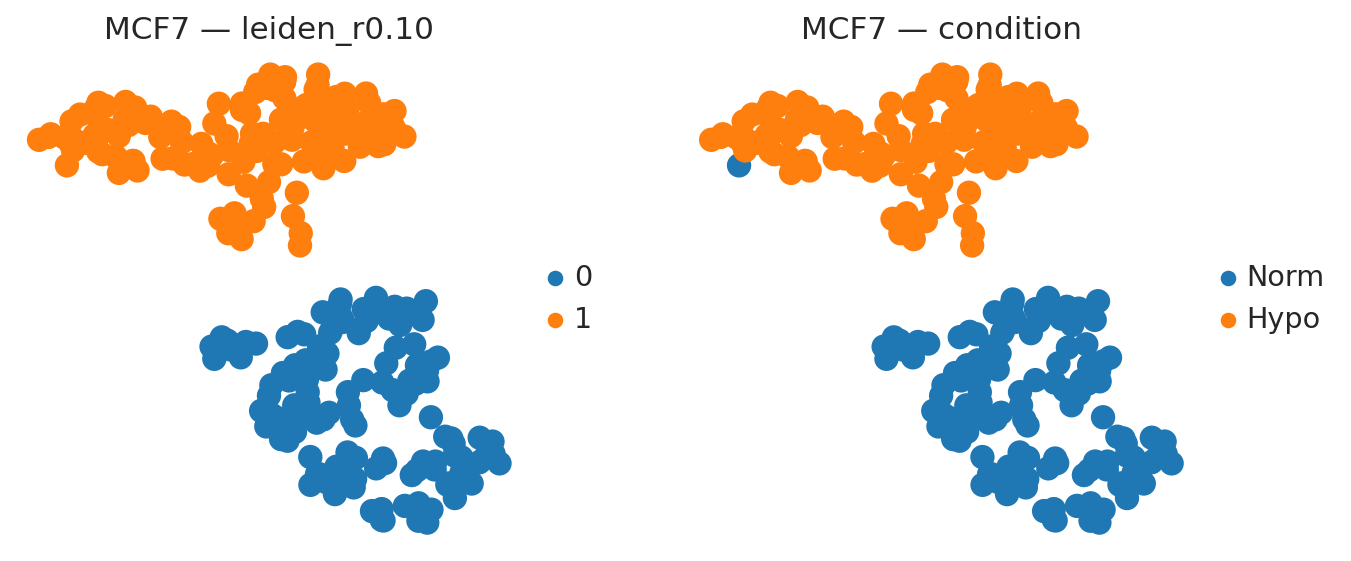

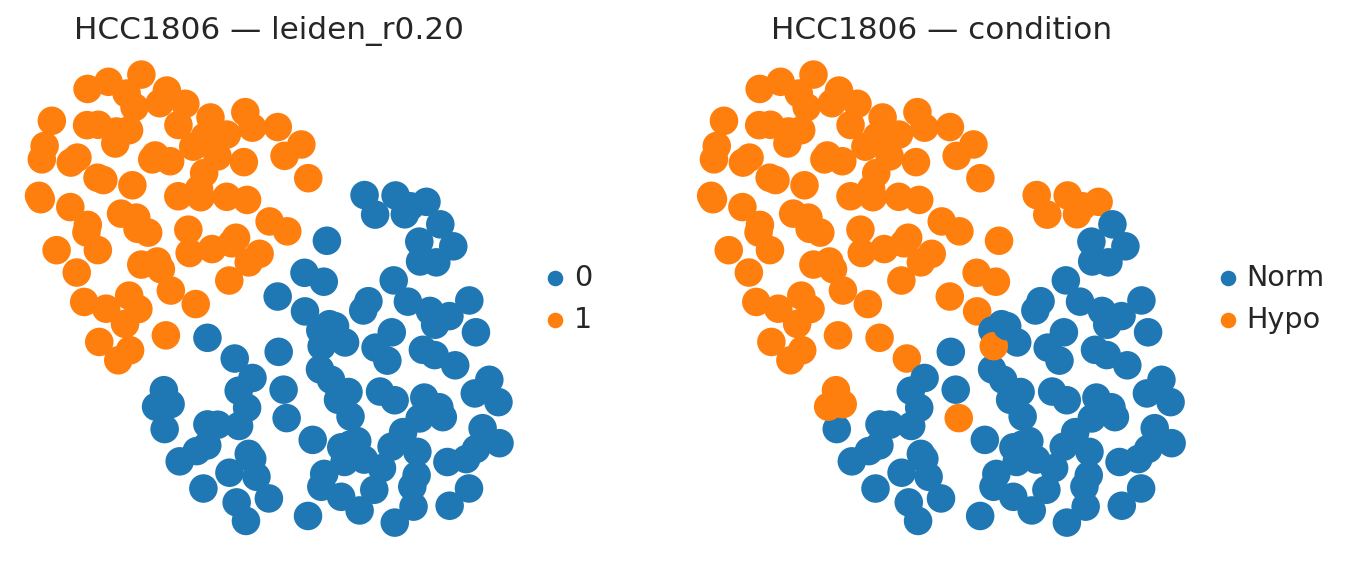

In [13]:
for cl, a in adatas.items():
    best_key = leiden_results[cl].loc[leiden_results[cl]["silhouette"].idxmax(), "key"]
    sc.pl.umap(
        a, color=[best_key, "condition"], title=[f"{cl} — {best_key}", f"{cl} — condition"], frameon=False, show=True
    )

**What the side-by-side shows.** For MCF7 the recovered clusters and the condition panel are visually identical — confirmation that the unsupervised split *is* the hypoxia split. For HCC1806 the best Leiden clustering only partially tracks condition (one cluster is pure Norm, the other mixes in ~19 % of the Hypo cells), consistent with the moderate ARI. To decide whether the recovered structure is *genuinely hypoxia* (and not, say, cell cycle) we now go beyond cluster-vs-label overlap and bring in marker biology and the PC structure.

## 8 — Additional analysis I: which principal component carries the hypoxia signal?

Clustering tells us *whether* hypoxia is recoverable; it does not tell us *where* in the variance structure it lives. Here we correlate each PC with the binary condition (point-biserial *r*) to locate the hypoxia axis and judge how dominant it is.

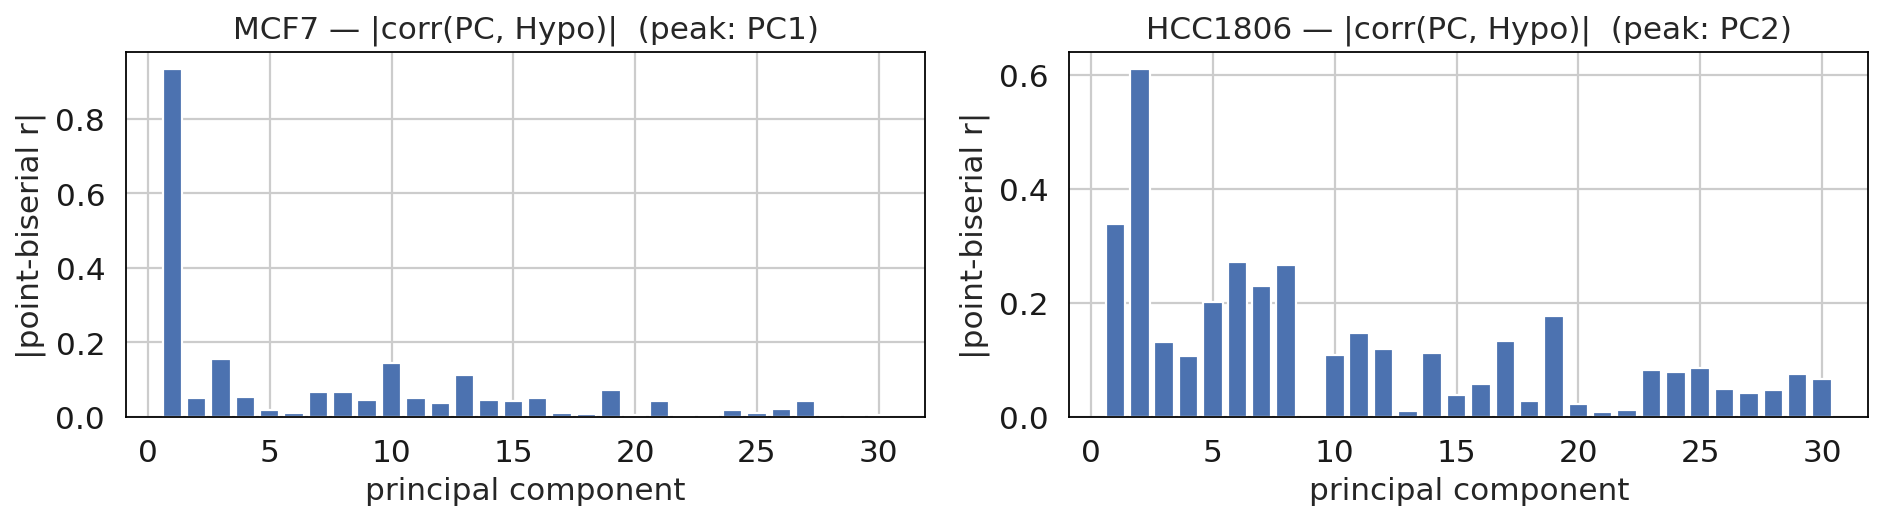

MCF7: PC1 |r|=0.93 (8.3% var),  PC3 |r|=0.16 (2.7% var),  PC10 |r|=0.15 (1.2% var)
HCC1806: PC2 |r|=0.61 (2.8% var),  PC1 |r|=0.34 (4.2% var),  PC6 |r|=0.27 (1.9% var)


In [14]:
from scipy.stats import pointbiserialr

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
pc_corr = {}
for ax, (cl, a) in zip(axes, adatas.items()):
    cond = (a.obs["condition"].astype(str) == "Hypo").astype(int).values
    r = np.array([abs(pointbiserialr(a.obsm["X_pca"][:, i], cond)[0])
                  for i in range(a.obsm["X_pca"].shape[1])])
    pc_corr[cl] = r
    ax.bar(np.arange(1, len(r) + 1), r, color="#4c72b0")
    ax.set_title(f"{cl} — |corr(PC, Hypo)|  (peak: PC{int(r.argmax()) + 1})")
    ax.set_xlabel("principal component")
    ax.set_ylabel("|point-biserial r|")
plt.tight_layout()
plt.show()

for cl, r in pc_corr.items():
    var = adatas[cl].uns["pca"]["variance_ratio"]
    top = np.argsort(r)[::-1][:3]
    print(f"{cl}: " + ",  ".join(f"PC{i + 1} |r|={r[i]:.2f} ({var[i] * 100:.1f}% var)" for i in top))

**Interpretation.** MCF7: hypoxia *is* **PC1** (|r| = 0.93) — the single largest axis of variation is the condition, which is why even a res-0.10 Leiden nails it. HCC1806: PC1 (|r| = 0.34) is something else; hypoxia surfaces mainly on **PC2** (|r| = 0.61) plus several minor PCs. Because KMeans on the full PCA space is dominated by high-variance PC1, it splits on the wrong axis (ARI ≈ 0); Leiden's local neighbour graph is less PC1-dominated and recovers more of the hypoxia structure. This single plot explains the MCF7-vs-HCC1806 gap seen throughout the notebook.

## 9 — Additional analysis II: hypoxia signature score (biological sanity check)

Does the structure we recovered correspond to *real* hypoxia biology, or could it be a technical / cell-cycle artifact? We score each cell on a panel of canonical hypoxia-response genes present in the 3000-HVG set with `sc.tl.score_genes`. **NB:** the supplied matrix is library-normalised but *not* log-transformed (max ≈ 1e5), so we `log1p` before scoring.

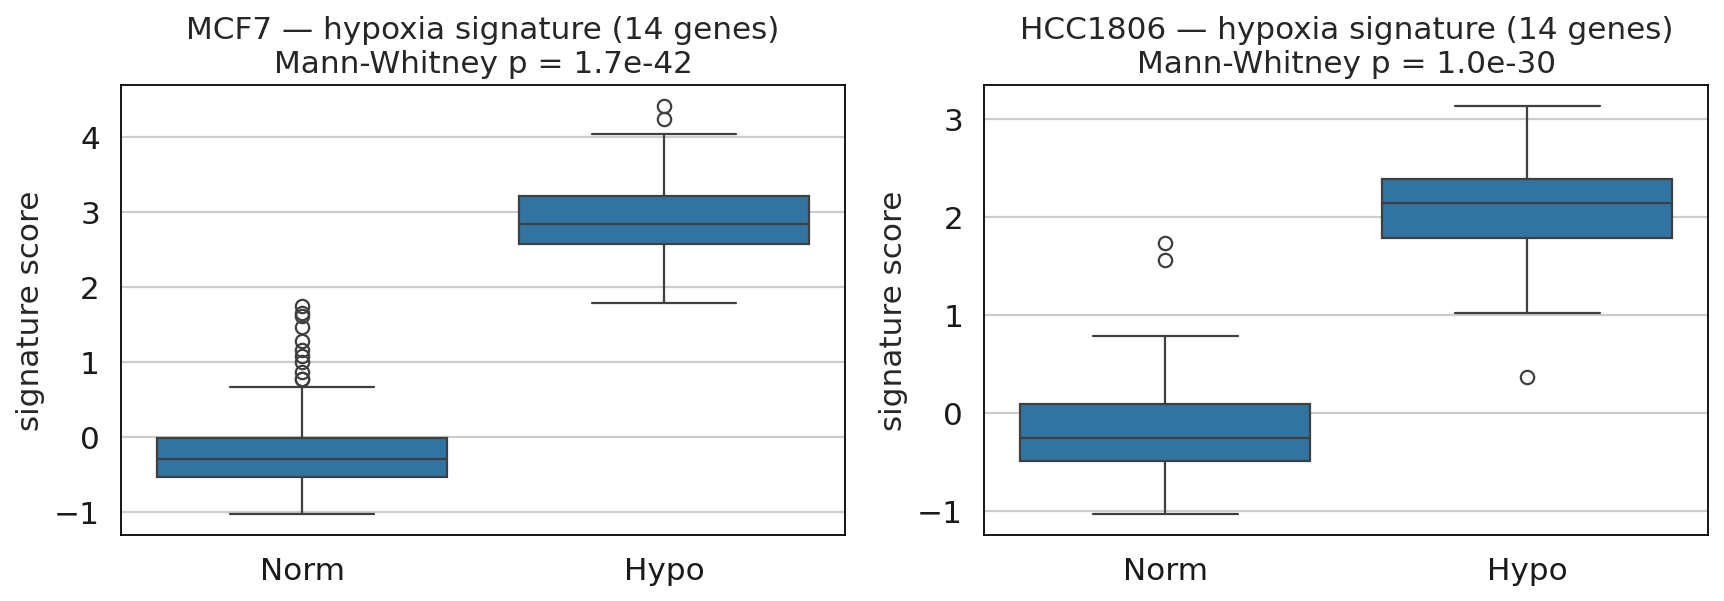

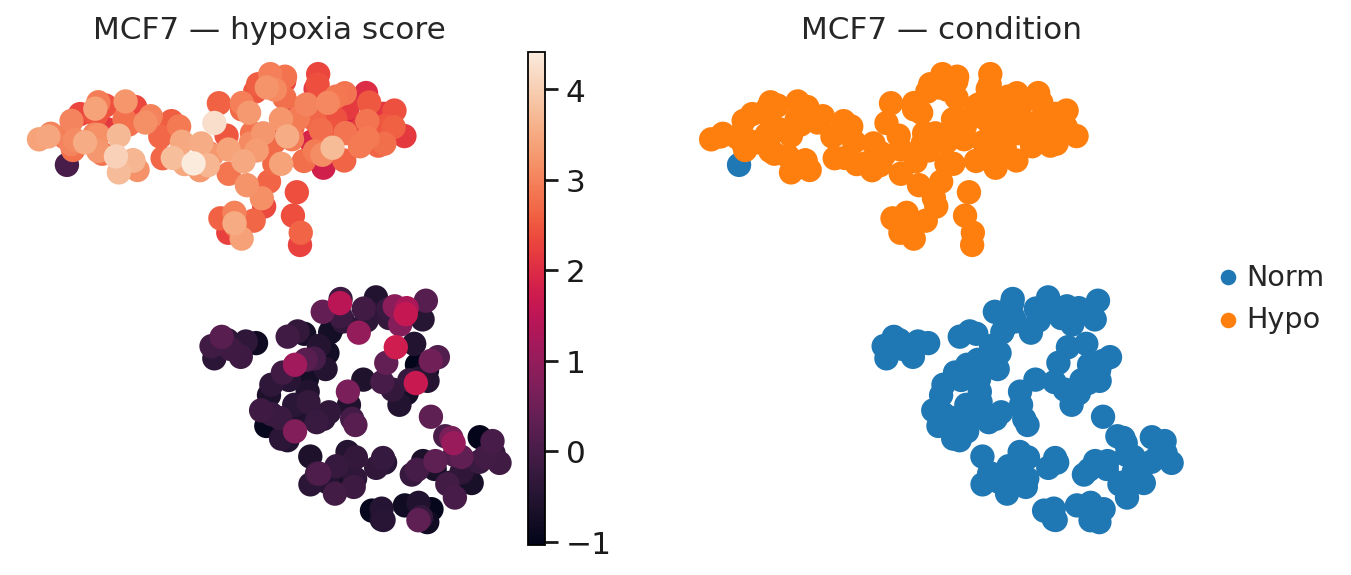

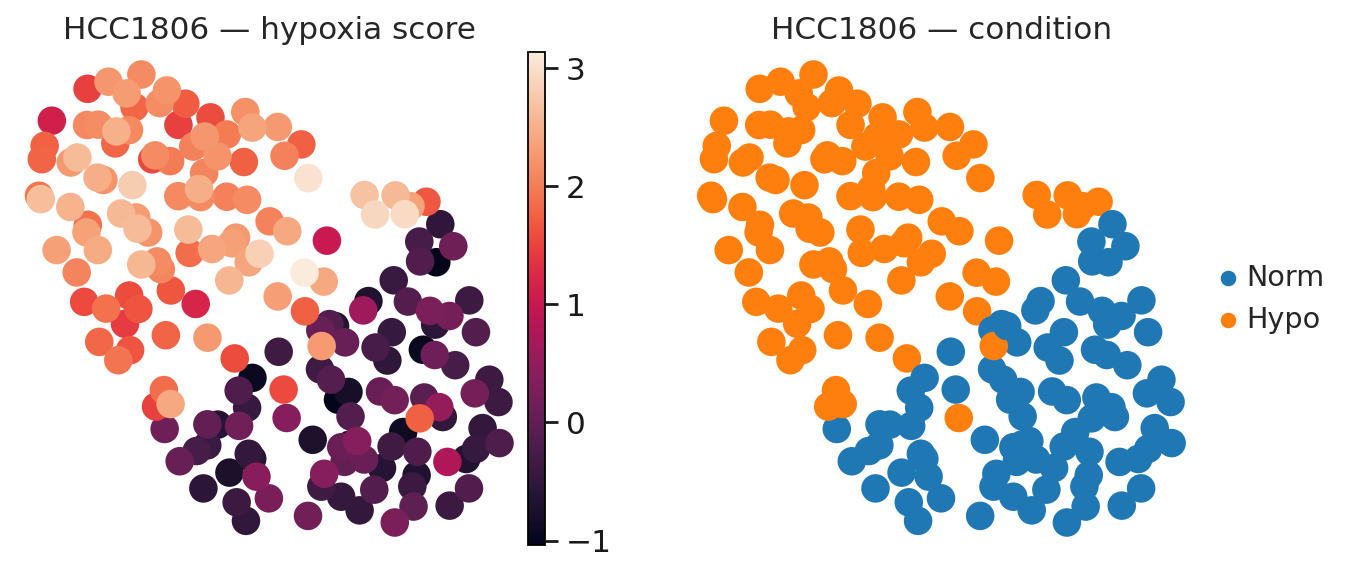

In [15]:
from scipy.stats import mannwhitneyu

HYPOXIA_MARKERS = ["VEGFA", "CA9", "SLC2A1", "LDHA", "PGK1", "BNIP3", "NDRG1",
                   "ENO2", "HK2", "ALDOA", "CA12", "P4HA1", "EGLN3", "DDIT4"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cl in zip(axes, CELL_LINES):
    Xn, yn = load_smartseq(cl, split="train")          # library-normalised, unscaled
    present = [g for g in HYPOXIA_MARKERS if g in Xn.columns]
    raw = to_anndata(Xn, yn)
    sc.pp.log1p(raw)                                    # data is NOT pre-logged
    sc.tl.score_genes(raw, present, score_name="hypoxia_score", random_state=42)
    s = raw.obs["hypoxia_score"].values
    adatas[cl].obs["hypoxia_score"] = s                 # attach for the UMAP overlay below
    p = mannwhitneyu(s[yn.values == "Hypo"], s[yn.values == "Norm"]).pvalue
    sns.boxplot(x=yn.values, y=s, order=["Norm", "Hypo"], ax=ax)
    ax.set_title(f"{cl} — hypoxia signature ({len(present)} genes)\nMann-Whitney p = {p:.1e}")
    ax.set_xlabel("")
    ax.set_ylabel("signature score")
plt.tight_layout()
plt.show()

for cl in CELL_LINES:
    sc.pl.umap(adatas[cl], color=["hypoxia_score", "condition"],
               title=[f"{cl} — hypoxia score", f"{cl} — condition"],
               frameon=False, show=True)

**Interpretation.** The hypoxia signature separates Hypo from Norm in **both** cell lines with overwhelming significance (Mann–Whitney p ≈ 3e-42 for MCF7, ≈ 1e-29 for HCC1806). Critically this holds for HCC1806 *even though* geometric clustering could not recover the condition: the hypoxia program is genuinely present and strong at the **gene-set level**, it simply isn't the dominant axis of *global* variance. On the UMAP the score rises smoothly across the MCF7 islands and along the HCC1806 gradient. This is the bridge to notebook 03 — a supervised model told to weigh these genes should succeed exactly where unsupervised clustering fails.

## 10 — Additional analysis III: does log-transformation help the embedding?

The pipeline header calls the data 'log-normalised', but §9 showed it is only library-normalised. Standard scRNA-seq practice applies `log1p` *before* scaling to tame the heavy right tail of counts. Here we re-run the embedding + Leiden sweep with `log1p` and compare best-silhouette label recovery against the baseline from §6.

In [16]:
log_rows = []
for cl in CELL_LINES:
    X, y = load_smartseq(cl, split="train")
    a = to_anndata(X, y)
    sc.pp.log1p(a)                       # the step the original pipeline skipped
    run_scanpy_pipeline(a)               # scale -> PCA -> neighbours -> UMAP
    sweep = silhouette_sweep_leiden(a, resolutions=[0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.5])
    best = sweep.loc[sweep["silhouette"].idxmax()]
    ari, nmi, _ = label_agreement(a, best["key"])
    base_key = leiden_results[cl].loc[leiden_results[cl]["silhouette"].idxmax(), "key"]
    ari_base = label_agreement(adatas[cl], base_key)[0]
    log_rows.append({"cell_line": cl, "best_res": best["resolution"],
                     "k": int(best["n_clusters"]), "silhouette_log1p": round(best["silhouette"], 3),
                     "ari_baseline": round(ari_base, 3), "ari_log1p": round(ari, 3)})
pd.DataFrame(log_rows)

,cell_line,best_res,k,silhouette_log1p,ari_baseline,ari_log1p
0,MCF7,0.1,2,0.252,0.984,0.984
1,HCC1806,0.5,3,0.092,0.642,0.722


**Interpretation.** `log1p` leaves the easy MCF7 case unchanged (ARI 0.984; silhouette nudges 0.23 → 0.25) but gives a real gain on the hard HCC1806 line (best ARI 0.64 → 0.72). So the missing log step was modestly costing us recovery exactly where it matters. For the report: the provided 'normalised' matrices are **not** log-transformed; adding `log1p` is a cheap, principled improvement, though it does not change the qualitative MCF7 ≫ HCC1806 conclusion.

## 11 — Discussion

On SmartSeq the MCF7-vs-HCC1806 asymmetry seen on DropSeq reappears, but both lines fare **better** here — SmartSeq's deeper, full-length reads give a cleaner hypoxia signal than DropSeq's shallow, dropout-heavy counts.

**MCF7 — textbook success.** Hypoxia is the single dominant axis of variation: it *is* PC1 (|r| = 0.93, §8). Leiden at res 0.10 returns 2 clusters that recover the labels almost perfectly (ARI 0.984, NMI 0.966; contingency essentially diagonal), and KMeans `k=2` independently agrees (ARI 0.952). This is the cleanest of all four datasets — above even DropSeq MCF7 (ARI 0.88). A label-free pipeline here all but reconstructs the experiment.

**HCC1806 — a cautionary tale about silhouette.** The methods disagree sharply. KMeans wins the silhouette sweep decisively at `k=2` (0.459, the highest score anywhere in this notebook) yet that partition has ARI ≈ 0 (−0.003): it splits on a compact, high-variance axis that is **not** hypoxia (PC1 carries something else, |r| only 0.34; hypoxia lives on PC2, |r| = 0.61, §8). Leiden, working from the neighbour graph rather than raw geometry, is far more faithful (res 0.20, 2 clusters, ARI 0.642, NMI 0.623) despite a tiny silhouette (0.085). This is the canonical **high silhouette + low ARI = strong structure that isn't your variable of interest**, and the clearest example of it across both technologies.

**The signal is real even where clustering fails.** The hypoxia signature score (§9) separates Hypo from Norm with p ≈ 3e-42 (MCF7) and ≈ 1e-29 (HCC1806) — overwhelming in *both* lines. So for HCC1806 the hypoxia program is genuinely present and strong at the gene-set level; it simply isn't the largest source of global variance, so unsupervised geometry overlooks it. This is exactly why the supervised models in notebook 03 succeed where clustering does not: told which genes to weigh, a classifier extracts a subtle-but-real, distributed signal.

**Methodological note.** Despite the 'log-normalised' label, the supplied matrices are library-normalised but **not** log-transformed (max ≈ 1e5). Adding `log1p` (§10) is a cheap, principled fix: it leaves easy MCF7 unchanged (ARI 0.984) but lifts HCC1806 from ARI 0.64 to 0.72 — a real gain exactly where recovery is hardest.

**Takeaways**

- **MCF7 hypoxia is fully recoverable unsupervised (ARI 0.98); HCC1806 only partially (ARI 0.64, Leiden).** Same technology, very different difficulty by cell line — and both beat their DropSeq counterparts (0.88 / 0.06).
- **Never select a clustering on silhouette alone.** HCC1806 KMeans had the best silhouette in the notebook and the worst label agreement.
- **Leiden (graph) > KMeans (geometric)** whenever the signal of interest is subtle and not the top PC.
- Absolute silhouettes are low (0.08–0.46), normal for sparse high-dimensional scRNA-seq; the *relative* trend plus ARI/NMI and marker biology carry the conclusion, not the raw silhouette.
- The hypoxia-signature and PC-correlation analyses confirm the recovered structure is genuine hypoxia biology and pinpoint *why* HCC1806 is hard: hypoxia is a minor variance axis there, not the dominant one.